In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import numpy as np
project_root = Path().resolve().parent
sys.path.append(str(project_root))
from scripts.rq2_function_lib import plot_national_fuel_prices_year, set_plot_style, load_brent, compute_ccf_year, load_merge_year, add_returns_and_lags, compute_ccf_from_prepared

set_plot_style()

# RQ: How do oil price changes affect retail fuel prices?

### • Is there a measurable and significant impact from oil to fuel prices?  
### • Does this transmission occur with a time lag?

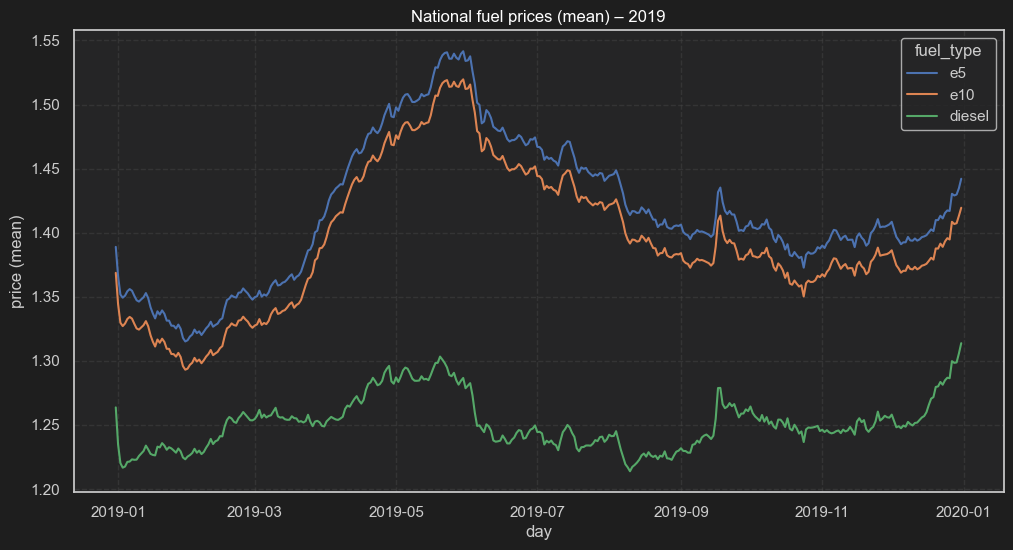

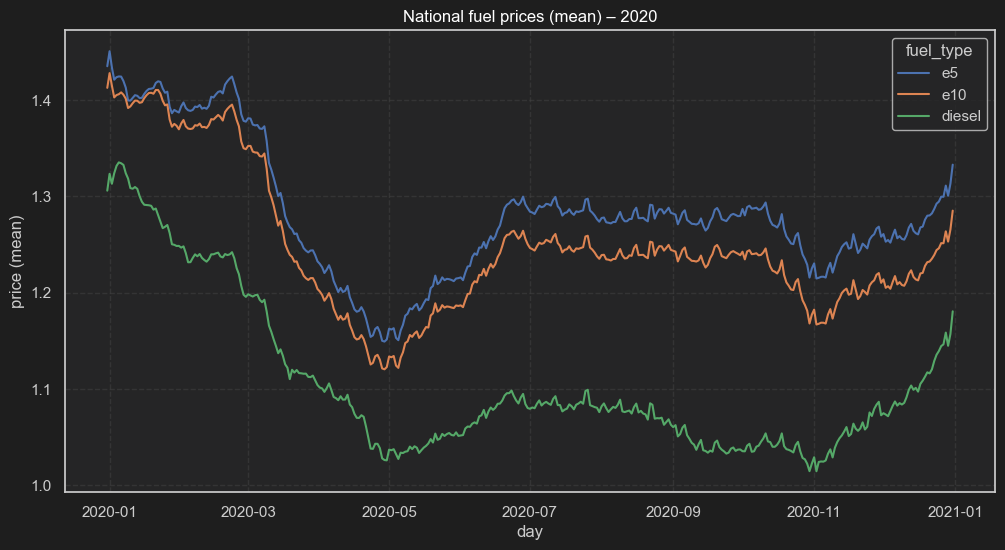

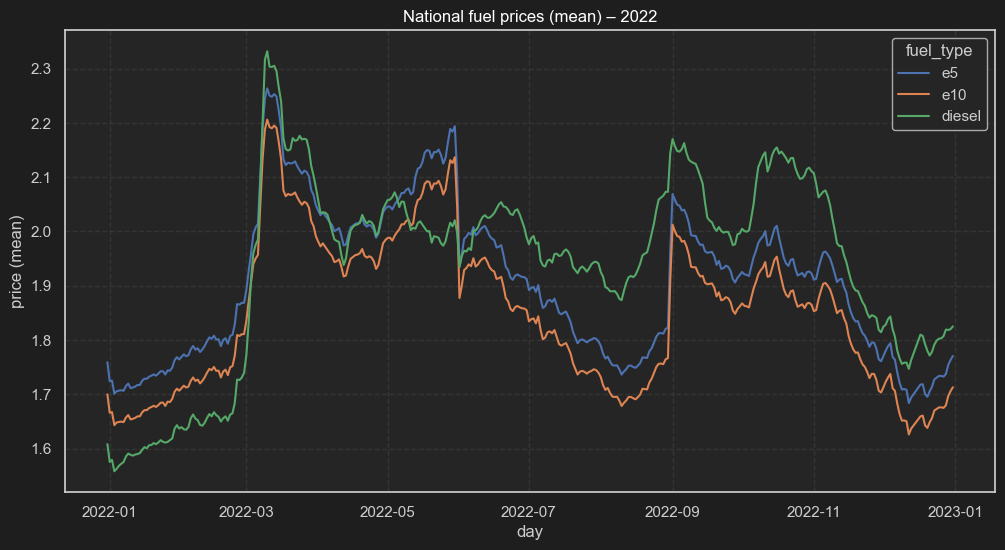

In [44]:
plot_national_fuel_prices_year(2019, stat="mean")
plot_national_fuel_prices_year(2020, stat="mean")
plot_national_fuel_prices_year(2022, stat="mean")

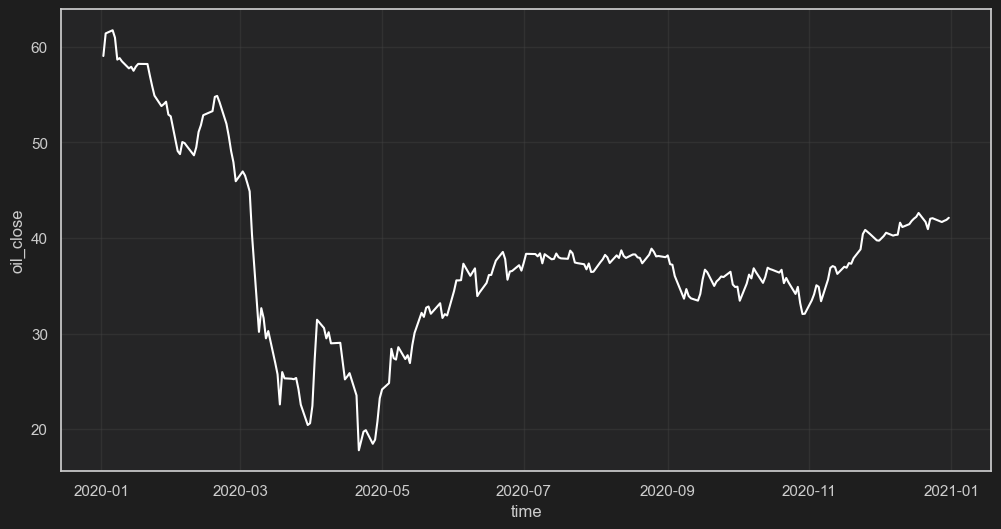

In [48]:
#--------------------------------------------------------
year = 2020 # change to which year you want to analyze
#--------------------------------------------------------

oil_d = load_brent(f"{year}-01-01", f"{year+1}-01-01", interval="1d")
oil_d.head()

plt.figure(figsize=(12, 6))
sns.lineplot(data=oil_d, x="time", y="oil_close", color="white")
plt.show()

fuel_path_d = Path(f"D:/data/derived/national_daily_last/national_daily_last_{year}.csv")
fuel_d = pd.read_csv(fuel_path_d)

oil_d["day"] = pd.to_datetime(oil_d["time"]).dt.normalize()
oil_d = oil_d[["day", "oil_close"]]

fuel_d["day"] = pd.to_datetime(fuel_d["day"]).dt.date
oil_d["day"] = pd.to_datetime(oil_d["day"]).dt.tz_localize(None).dt.date


### Merging oil and fuel, calculating Cross-Correlation-Function + 95% Confidence interval to check which lag is significant

In [58]:
#--------------------------------------------------------------------
fuel_type = "diesel_mean_last" # change this to fuel type of interest
K_LAG = 50 # set maximum number of lags for CCF
#--------------------------------------------------------------------

fuel_d_small = fuel_d[["day", f"{fuel_type}"]]

# merge of fuel and oil dataframes and forward-fill oil prices to align with fuel data, then drop any remaining NaNs
merged_fill = fuel_d_small.merge(oil_d, on="day", how="left").sort_values("day")
merged_fill["oil_close"] = merged_fill["oil_close"].ffill()
merged_fill = merged_fill.dropna(subset=["oil_close", f"{fuel_type}"]).reset_index(drop=True)

merged_fill.head(10)

,day,diesel_mean_last,oil_close
0,2020-01-02,1.313088,59.042000
1,2020-01-03,1.323958,61.406599
2,2020-01-04,1.331634,61.406599
3,2020-01-05,1.335300,61.406599
4,2020-01-06,1.334390,61.736470
5,2020-01-07,1.332686,60.966268
6,2020-01-08,1.324054,58.665653
7,2020-01-09,1.318516,58.821886
8,2020-01-10,1.308643,58.482000
9,2020-01-11,1.307924,58.482000


### Using
Log-Return:
$$r_t = \log(P_t) - \log(P_{t-1}) = \log\left(\frac{P_t}{P_{t-1}}\right)$$
therefore we get approximate %-change (for smaller changes):
$$r_t \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$
thus the process is now $\approx$ stationary.
Now you can use the Cross-Correlation-Function (CCF):
$$\text{corr}(r_t^{fuel}, r_{t-k}^{oil})$$
### Significance of Cross-Correlations
To determine whether a correlation is statistically significant we use an approximate **95\% confidence interval**.  
A lag $k$ is considered statistically significant if
$$
|\hat{\rho}_k| > \frac{1.96}{\sqrt{N}}
$$
In the CCF plot these thresholds appear as horizontal dashed lines.  
Any lag outside this band indicates a statistically significant relationship
between oil price changes and fuel price changes.

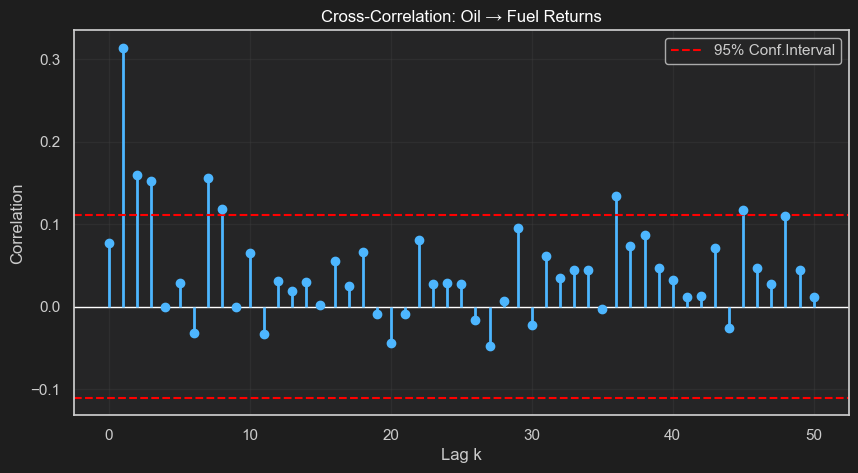

In [59]:
df_corr = merged_fill.copy()

df_corr["r_fuel"] = np.log(df_corr[f"{fuel_type}"]).diff()
df_corr["r_oil"] = np.log(df_corr["oil_close"]).diff()
df_corr = df_corr.dropna(subset=["r_fuel", "r_oil"]).reset_index(drop=True) # delete first row due to diff and potential other NaNs

# use vectorized approach to create lagged columns for r_oil (AND better performance):
lags = pd.concat([df_corr["r_oil"].shift(k) for k in range(K_LAG + 1)], axis=1)
lags.columns = [f"r_oil_lag{k}" for k in range(K_LAG + 1)]
df_corr = pd.concat([df_corr, lags], axis=1)

lag_cols = lags.columns
data_corr = df_corr.dropna(subset=list(lag_cols) + ["r_fuel"])

# compute CCF
corr_values = data_corr[lag_cols].corrwith(data_corr["r_fuel"])
ccf_df = pd.DataFrame({
    "lag_days": np.arange(K_LAG + 1),
    "corr": corr_values.to_numpy()
})

# plot CCF with confidence intervals
N = len(data_corr)
conf = 1.96 / np.sqrt(N)  # 95% confidence interval for correlation (for larger samples)

lags = ccf_df["lag_days"]
corr = ccf_df["corr"]

plt.figure(figsize=(10,5))
plt.axhline(0, color="white", linewidth=1)
plt.vlines(lags, 0, corr, color="#4db6ff", linewidth=2)
plt.scatter(lags, corr, color="#4db6ff", zorder=3)
plt.axhline(conf, color="red", linestyle="--", label="95% Conf.Interval") # confidence interval
plt.axhline(-conf, color="red", linestyle="--")
plt.xlabel("Lag k")
plt.ylabel("Correlation")
plt.title("Cross-Correlation: Oil → Fuel Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Result of yearwise analysis
The CCF is different for every year, nevertheless it is possible to conclude, by looking at every year  
individually, that the **1st, 2nd and 3rd lag** are the most signifikant ones  
## =========================================
# NOW: Aggregaded data from 2014 to 2026:
### Cross-Correlation Analysis

To analyze how oil price changes relate to fuel prices, we again compute the cross-correlation function (CCF) between oil returns and fuel returns for lags $k = 0, \dots$,  
but now for all yeats combined (2014–2025) instead of only looking at one year individually.

So we again use:

$$\rho_k = \text{corr}(r_t^{fuel}, r_{t-k}^{oil})$$

where $r_t$ denotes the log-return of the respective price series.  

The resulting correlations are stored in a matrix with **years as rows** and **lags as columns**, which allows us to visualize the lag structure across years and to compute the average correlation.

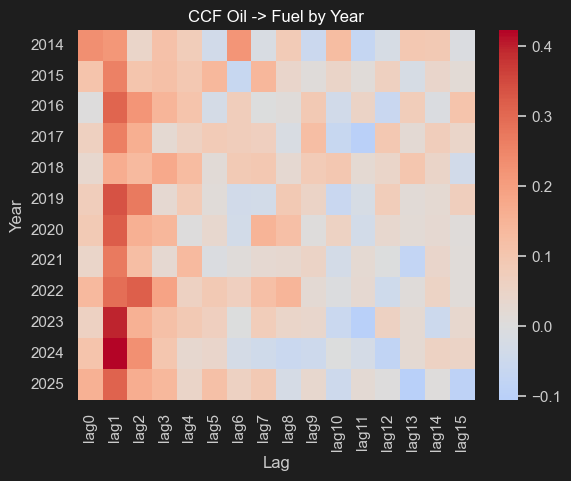

In [60]:
years = range(2014, 2026)

ccf_all = []
for y in years:
    corr = compute_ccf_year(y, fuel_type=fuel_type, K_LAG=15)
    ccf_all.append(corr)

ccf_all = pd.DataFrame(ccf_all)
ccf_all.index = years
mean_ccf = ccf_all.mean()

# Plot heatmap of CCFs by year
sns.heatmap(ccf_all,cmap="coolwarm",center=0)
plt.xlabel("Lag")
plt.ylabel("Year")
plt.title("CCF Oil -> Fuel by Year")

# Plot average CCF across years with confidence intervals
lags = np.arange(len(mean_ccf))
N = 365 * len(years)
conf = 1.96 / np.sqrt(N)

# plt.figure(figsize=(10,5))
# plt.axhline(0,color="white")
# plt.vlines(lags,0,mean_ccf,color="#4db6ff")
# plt.scatter(lags,mean_ccf,color="#4db6ff")
# plt.axhline(conf,color="red",linestyle="--", label="95% Conf.Interval")
# plt.axhline(-conf,color="red",linestyle="--")
# plt.xlabel("Lag k")
# plt.ylabel("Correlation")
# plt.title("Average Cross-Correlation (Oil -> Fuel)")
# plt.legend()
# plt.grid(alpha=0.3)
plt.show()

### Lag Selection

The heatmap shows a consistent pattern across years with the strongest correlations occurring for lags $k = 1, 2, 3$.  
Beyond lag 3, the correlations become small and and therefore we choose a lag of 3 for our model.

Based on this, we select the maximum lag length of

$$K = 3$$

for our Regression model.

### Distributed Lag Model

Using the selected lag structure, the relationship between oil and fuel returns is modeled as

$$r_t^{fuel} = \alpha + \beta_0 r_t^{oil} + \beta_1 r_{t-1}^{oil} + \beta_2 r_{t-2}^{oil} + \beta_3 r_{t-3}^{oil} + \varepsilon_t$$

where $r_t^{fuel}$ and $r_t^{oil}$ denote the log-returns of fuel and oil prices.  

The coefficients $\beta_k$ measure the **pass-through**, i.e., the extent to which changes in oil prices are transmitted to fuel prices. In particular, $\beta_k$ captures how strongly an oil price change occurring $k$ days earlier affects the fuel price return today, thereby describing the delayed adjustment of fuel prices to oil price shocks.

In [61]:
K = 3

parts = []
for y in years:
    merged = load_merge_year(y, fuel_type=fuel_type, interval="1d")
    prep = add_returns_and_lags(merged, K_LAG=K) 
    prep = prep.copy()
    prep["year"] = y
    parts.append(prep)

df_all = (
    pd.concat(parts, ignore_index=True)
      .sort_values("day")
      .reset_index(drop=True)
)
data_model = df_all[["day", "year", "r_fuel"] + [f"r_oil_lag{k}" for k in range(K+1)]].dropna()
df_all.head()

,day,fuel_price,oil_close,r_fuel,r_oil,r_oil_lag0,r_oil_lag1,r_oil_lag2,r_oil_lag3,year
0,2014-06-13,1.420051,83.669366,0.009637,0.002158,0.002158,0.027823,0.007731,-0.000592,2014
1,2014-06-14,1.424649,83.669366,0.003232,0.000000,0.000000,0.002158,0.027823,0.007731,2014
2,2014-06-15,1.414931,83.669366,-0.006845,0.000000,0.000000,0.000000,0.002158,0.027823,2014
3,2014-06-16,1.424391,83.631081,0.006664,-0.000458,-0.000458,0.000000,0.000000,0.002158,2014
4,2014-06-17,1.416944,83.559324,-0.005242,-0.000858,-0.000858,-0.000458,0.000000,0.000000,2014


In [62]:
import statsmodels.api as sm

X = data_model[[f"r_oil_lag{k}" for k in range(K+1)]]
X = sm.add_constant(X)

y = data_model["r_fuel"]

ols = sm.OLS(y, X).fit()
ols_hac = ols.get_robustcov_results(cov_type="HAC", maxlags=7)
print(ols_hac.summary())

                            OLS Regression Results                            
Dep. Variable:                 r_fuel   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     25.75
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           4.15e-21
Time:                        12:16:00   Log-Likelihood:                 16425.
No. Observations:                4155   AIC:                        -3.284e+04
Df Residuals:                    4150   BIC:                        -3.281e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.511e-05   8.71e-05      0.518      0.6

# **Intermediate Results**

### **Result 1 – Lag structure**

Oil price changes transmit to fuel prices within a delay of roughly **1–3 days**.  

### **Result 2 – Timing of the pass-through**

The strongest pass-through occurs **one day after the oil price change**.  
This suggests that fuel retailers adjust prices with a short delay.

### **Result 3 – Magnitude of the explained variation**

The model explains around **10%-16%** (depending on which fuel type you obeserve) **of the variation in fuel price returns**.  
While this may appear small at first, it is economically meaningful given that a large share of retail fuel prices consists of **fixed taxes and duties (roughly 60%)**, which do not respond to oil price changes.  
The regression therefore captures a substantial part of the **variable component of fuel prices**.

### **Result 4 – Stronger response for diesel**

The estimated coefficients indicate that **diesel prices react more strongly to oil price changes than gasoline prices**.  
This pattern is also consistent with historical market observations.

Periods of supply disruptions or geopolitical shocks often amplify this effect.  
For example, during the **early phase of the Ukraine war** and again during recent **Middle East tensions**, diesel prices increased more strongly than gasoline prices, sometimes even exceeding gasoline prices.  
This phenomenon is analyzed in more detail in **Research Question 5**, which examines structural differences between fuel types.

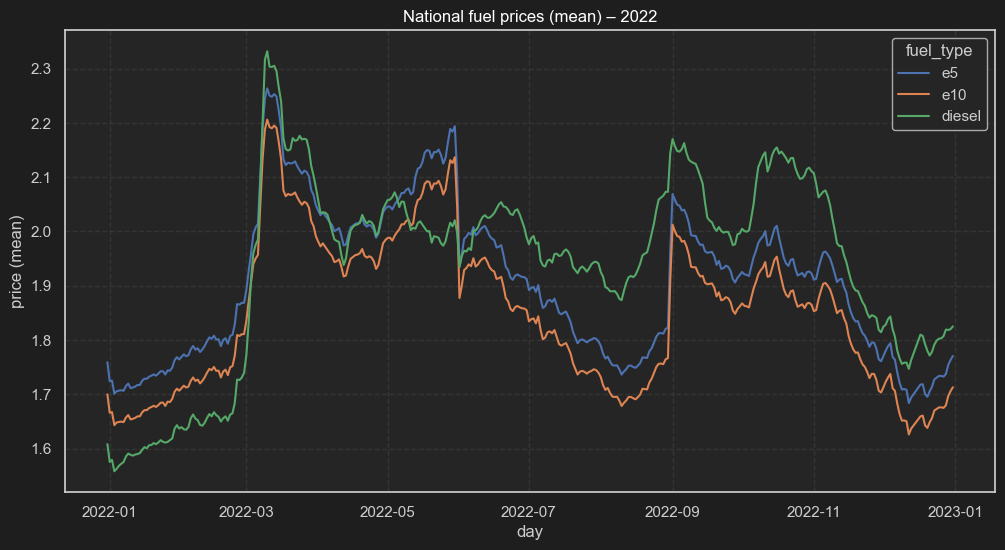

In [63]:
# Examplary plot for the beginning of the Ukraine war in feb/march 2022
plot_national_fuel_prices_year(2022, stat="mean")

### Asymmetric pass-through of oil price changes

In the previous section, we estimated a distributed lag model assuming that **oil price increases and decreases affect fuel prices symmetrically**.  
However, it might be interesting to quantify if there are asymmetries in the oil price fluctuations.

This refers, for example, to the observation that fuel prices tend to **increase rapidly when oil prices rise**, but **decrease more slowly when oil prices fall**.

To test this, oil price returns are seperated into **positive and negative components**:

$$r^{oil,+}_t = \max(r^{oil}_t, 0), \qquad r^{oil,-}_t = \min(r^{oil}_t, 0)$$

Lagged versions of both components are then included in the regression model:

$$r_t^{fuel} = \alpha + \sum_{k=0}^{3} \beta_k^{+} r_{t-k}^{oil,+} + \sum_{k=0}^{3} \beta_k^{-} r_{t-k}^{oil,-} + \varepsilon_t$$

This specification allows **positive and negative oil price changes to have different effects** on fuel price adjustments.

To formally test whether the responses differ, a **Hypothesis Test (Wald)** is conducted with the hypothesis being:

$$H_0: \beta_k^{+} = \beta_k^{-} \quad \forall k \qquad \text{vs.} \qquad H_1: \beta_k^{+} \neq \beta_k^{-} \quad \text{for at least one } k \qquad \text{with} \qquad \alpha = 0.05$$

Rejecting $H_0$ implies that **positive and negative oil price changes have statistically different effects on fuel prices**.

In [64]:
df_asym = data_model.copy()

# build pos/neg from existing lag columns
for k in range(K+1):
    col = f"r_oil_lag{k}"
    df_asym[f"r_oil_pos_lag{k}"] = df_asym[col].clip(lower=0)
    df_asym[f"r_oil_neg_lag{k}"] = df_asym[col].clip(upper=0)

pos_cols = [f"r_oil_pos_lag{k}" for k in range(K+1)]
neg_cols = [f"r_oil_neg_lag{k}" for k in range(K+1)]

df_asym = df_asym.dropna(subset=["r_fuel"] + pos_cols + neg_cols).reset_index(drop=True)


pos_cols = [f"r_oil_pos_lag{k}" for k in range(K+1)]
neg_cols = [f"r_oil_neg_lag{k}" for k in range(K+1)]

X = df_asym[pos_cols + neg_cols]
X = sm.add_constant(X)
y = df_asym["r_fuel"]

ols_asym = sm.OLS(y, X).fit()
ols_asym_hac = ols_asym.get_robustcov_results(cov_type="HAC", maxlags=14)

print(ols_asym_hac.summary())

                            OLS Regression Results                            
Dep. Variable:                 r_fuel   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     29.14
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.28e-44
Time:                        12:16:00   Log-Likelihood:                 16486.
No. Observations:                4155   AIC:                        -3.295e+04
Df Residuals:                    4146   BIC:                        -3.290e+04
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.125e-05      0.000      0.

In [65]:
names = list(X.columns)  # includes const
p = len(names)

R = np.zeros((K+1, p))

for k in range(K+1):
    R[k, names.index(f"r_oil_pos_lag{k}")] = 1
    R[k, names.index(f"r_oil_neg_lag{k}")] = -1

wald = ols_asym_hac.wald_test(R)

print(wald)

<F test: F=array([[9.67605137]]), p=8.694577236726548e-08, df_denom=4.15e+03, df_num=4>


c:\dev\Data-Science-Projekt\venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


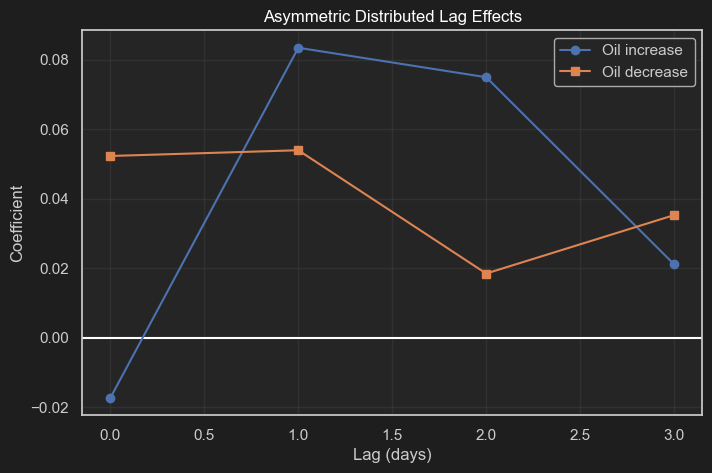

In [66]:
pos_cols = [f"r_oil_pos_lag{k}" for k in range(K+1)]
neg_cols = [f"r_oil_neg_lag{k}" for k in range(K+1)]

names = list(X.columns)
params = dict(zip(names, ols_asym_hac.params))
bse = dict(zip(names, ols_asym_hac.bse))
beta_pos = np.array([params[c] for c in pos_cols])
beta_neg = np.array([params[c] for c in neg_cols])
se_pos = np.array([bse[c] for c in pos_cols])
se_neg = np.array([bse[c] for c in neg_cols])
lags = np.arange(K+1)

plt.figure(figsize=(8,5))
plt.errorbar(
    lags,
    beta_pos,
    fmt="o-",
    label="Oil increase",
)
plt.errorbar(
    lags,
    beta_neg,
    fmt="s-",
    label="Oil decrease",
)
plt.axhline(0,color="white")
plt.xlabel("Lag (days)")
plt.ylabel("Coefficient")
plt.title("Asymmetric Distributed Lag Effects")
plt.legend()
plt.show()

### Results of the asymmetry analysis

The hypothesis test rejects the null hypothesis of symmetric transmission, indicating that **positive and negative oil price changes lead to different adjustment patterns in fuel prices**.

The figure above visualizes the lagged coefficients for oil price increases and decreases. Interestingly, the adjustment pattern does not follow a simple structure across all lags. While differences between the responses are visible, the strongest effects occur with a short delay rather than immediately (already seen before).

From an economic perspective, one might expect fuel prices to **increase rapidly when oil prices rise but decrease more slowly when oil prices fall**, since retailers may try to maintain higher margins when costs decline.  

However, the estimated lag structure suggests a more complex dynamic adjustment process, where the timing and magnitude of the response differ across lags rather than showing a simple immediate asymmetry.